# Question 1 — Implement Convolution from Scratch

In [1]:
import numpy as np

# a. Store the input and filter using NumPy arrays
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

filter_matrix = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

stride = 1
padding = 0

# Input and filter sizes
input_height, input_width = input_matrix.shape
filter_height, filter_width = filter_matrix.shape

# Calculate output size
output_height = (input_height - filter_height + 2 * padding) // stride + 1
output_width = (input_width - filter_width + 2 * padding) // stride + 1

# Create output matrix
output = np.zeros((output_height, output_width), dtype=int)

# b. Slide the filter over the input matrix
for i in range(output_height):
    for j in range(output_width):

        # Extract the current 3x3 region
        region = input_matrix[
            i * stride : i * stride + filter_height,
            j * stride : j * stride + filter_width
        ]

        # c. Compute the dot product
        output[i, j] = np.sum(region * filter_matrix)

# d. Print complete output feature map
print("Output feature map:")
print(output)

# e. Print output shape
print("Output shape:", output.shape)

Output feature map:
[[4 3 4]
 [2 4 3]
 [2 3 4]]
Output shape: (3, 3)


f. Briefly explain how changing the stride from 1 to 2 would affect the output.  
Changing the stride from 1 to 2 means the filter moves two positions at a time instead of one. Therefore, fewer positions are evaluated, and the output feature map becomes smaller. In this example, the output shape changes from (3,3) to (2,2).

# Question 2 — Transfer Learning: Freeze vs. Fine-Tune

Device: cpu
Classes: ['ants', 'bees']
Training images: 244
Validation images: 153

Experiment A: Feature Extraction
Trainable Parameters: 1026
Epoch 1/5, Loss: 0.6634
Epoch 2/5, Loss: 0.6304
Epoch 3/5, Loss: 0.6003
Epoch 4/5, Loss: 0.5480
Epoch 5/5, Loss: 0.5308
Training Time: 52.77 seconds
Validation Accuracy: 80.39%

Experiment B: Fine-Tuning
Trainable Parameters: 8394754
Epoch 1/5, Loss: 0.3892
Epoch 2/5, Loss: 0.0884
Epoch 3/5, Loss: 0.0564
Epoch 4/5, Loss: 0.0336
Epoch 5/5, Loss: 0.0428
Training Time: 79.32 seconds
Validation Accuracy: 92.81%

Comparison
Method                      Parameters        Time(s)        Accuracy    
-------------------------------------------------------------------------
Frozen Feature Extractor    1026              52.77          80.39%
Fine-Tuned Network          8394754           79.32          92.81%


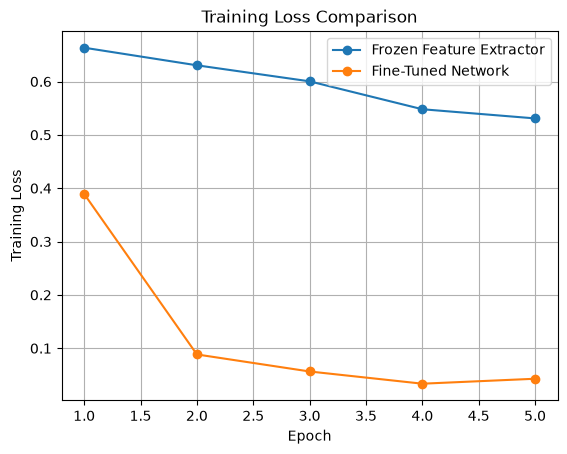

In [2]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


# 1. Basic settings

torch.manual_seed(42)

# Use GPU if available; otherwise use CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

data_dir = r"C:\Users\ruyi4\Desktop\hymenoptera_data"

# Hyperparameters
num_classes = 2
batch_size = 16
num_epochs = 5
learning_rate = 0.0001


# 2. Image preprocessing

# Training data includes simple data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation data does not use random augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# 3. Load dataset

train_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(data_dir, "val"),
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))


# 4. Count trainable parameters

def count_trainable_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


# 5. Training function

def train_model(model, train_loader, epochs, learning_rate):

    criterion = nn.CrossEntropyLoss()

    # Update only parameters that are not frozen
    optimizer = optim.Adam(
        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),
        lr=learning_rate
    )

    training_losses = []
    start_time = time.perf_counter()

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backpropagation and parameter update
            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

        # Average loss for the current epoch
        epoch_loss = (
            running_loss /
            len(train_loader.dataset)
        )

        training_losses.append(epoch_loss)

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {epoch_loss:.4f}"
        )

    training_time = (
        time.perf_counter() - start_time
    )

    return training_losses, training_time


# 6. Evaluation function

def evaluate_model(model, val_loader):

    model.eval()

    correct = 0
    total = 0

    # Gradients are not needed during evaluation
    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = (
        100 * correct / total
    )

    return accuracy


# Experiment A — Frozen Feature Extractor

print("\n==============================")
print("Experiment A: Feature Extraction")
print("==============================")

# Load pretrained ResNet18
model_A = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Freeze all pretrained layers
for param in model_A.parameters():
    param.requires_grad = False

# Replace the final classifier for two classes
model_A.fc = nn.Linear(
    model_A.fc.in_features,
    num_classes
)

model_A = model_A.to(device)

trainable_A = count_trainable_parameters(
    model_A
)

print(
    "Trainable Parameters:",
    trainable_A
)

loss_A, time_A = train_model(
    model_A,
    train_loader,
    num_epochs,
    learning_rate
)

accuracy_A = evaluate_model(
    model_A,
    val_loader
)

print(
    f"Training Time: {time_A:.2f} seconds"
)

print(
    f"Validation Accuracy: "
    f"{accuracy_A:.2f}%"
)


# Experiment B — Fine-Tuning

print("\n==============================")
print("Experiment B: Fine-Tuning")
print("==============================")

# Load a fresh pretrained ResNet18
model_B = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Freeze all layers first
for param in model_B.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block
for param in model_B.layer4.parameters():
    param.requires_grad = True

# Replace the final classifier
model_B.fc = nn.Linear(
    model_B.fc.in_features,
    num_classes
)

model_B = model_B.to(device)

trainable_B = count_trainable_parameters(
    model_B
)

print(
    "Trainable Parameters:",
    trainable_B
)

loss_B, time_B = train_model(
    model_B,
    train_loader,
    num_epochs,
    learning_rate
)

accuracy_B = evaluate_model(
    model_B,
    val_loader
)

print(
    f"Training Time: {time_B:.2f} seconds"
)

print(
    f"Validation Accuracy: "
    f"{accuracy_B:.2f}%"
)


# 7. Compare results

print("\n==============================================")
print("Comparison")
print("==============================================")

print(
    f"{'Method':<28}"
    f"{'Parameters':<18}"
    f"{'Time(s)':<15}"
    f"{'Accuracy':<12}"
)

print("-" * 73)

print(
    f"{'Frozen Feature Extractor':<28}"
    f"{trainable_A:<18}"
    f"{time_A:<15.2f}"
    f"{accuracy_A:.2f}%"
)

print(
    f"{'Fine-Tuned Network':<28}"
    f"{trainable_B:<18}"
    f"{time_B:<15.2f}"
    f"{accuracy_B:.2f}%"
)


# 8. Plot training loss

epochs = range(
    1,
    num_epochs + 1
)

plt.plot(
    epochs,
    loss_A,
    marker="o",
    label="Frozen Feature Extractor"
)

plt.plot(
    epochs,
    loss_B,
    marker="o",
    label="Fine-Tuned Network"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid()

plt.show()

The frozen feature extractor had fewer trainable parameters because only the final classification layer was trained. Therefore, it required less training time. The fine-tuned network had many more trainable parameters because the last convolutional block and classifier were both updated. Fine-tuning usually takes longer because more parameters require gradient calculations and updates. However, fine-tuning allows the pretrained features to adapt to the new ants-and-bees dataset. This may improve validation accuracy compared with using completely frozen features. Overall, feature extraction is faster, while fine-tuning may provide better performance.